In [37]:
import serial
from ReadWrite import ReadWrite
import pandas as pd
from matplotlib import pyplot as plt
from Network import RKMNetwork
from func_timeout import func_timeout, FunctionTimedOut
import time
import ast
import numpy as np
from datetime import datetime
import matplotlib as mpl
import scipy
import json
# print(scipy.__version__)
# from scipy.interpolate import make_smoothing_spline

# from scipy.interpolate import UnivariateSpline as make_smoothing_spline

import os
lam = 20
import random

In [76]:
port = "/dev/ttyACM1" # Replace with your serial port
baudrate = 250000
ser = serial.Serial(port, baudrate)
ser.is_open

True


  name  isWeight Anode Bnode
0  BV0         0    A0    V0
1  BV1         0    A0    V1
2  BH0         0    A0    H0
3  BH1         0    A0    H1
4  W00         1    V0    H0
5  W01         1    V0    H1
6  W10         1    V1    H0
7  W11         1    V1    H1


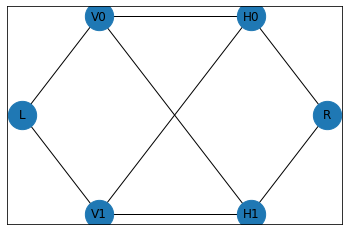

In [77]:
numV = 2
numH = 2

net = RKMNetwork(numV,numH)

net.draw_network()

print(net.edge)
# print(net.node)

In [78]:
aConvert = (3.3)/(4095.)

def cleanup_ames(thisdict):
    aConvert = (3.3)/(4095.)
    nmestimes = int(thisdict['nmestimes'])
    aConvert = aConvert*1/nmestimes
    newdict = {}
    
    azero = np.array(thisdict['analogZero'], dtype='float')*aConvert
    newdict['analogZero'] = azero

    try:
        analogV = thisdict['analogV']
        for i, val in enumerate(analogV):
            newdict['aV' + str(i)] = val*aConvert
    except:
        pass
            
    try:
        analogH = thisdict['analogH']
        for i, val in enumerate(analogH):
            newdict['aH' + str(i)] = val*aConvert
    except:
        pass
        
    return newdict

In [79]:
RW = ReadWrite(ser)

In [80]:
outs = []
Ntrials = 5

RW.send_recieve('reset;')
time.sleep(1)
RW.send_recieve('mes;')
time.sleep(1)

RW.send_recieve('fb;1;')
RW.send_recieve('clamp;0;0;')
time.sleep(1)
for i in range(Ntrials):
    RW.send_message('ames;1;')
    out = RW.measure()
    time.sleep(1.)
    RW.send_message('ames;0;')
    out2 = RW.measure()
    out.update(out2)
    time.sleep(1.)
    out = cleanup_ames(out)
    outs.append(out)
    
ames = pd.DataFrame(outs)
ames

reset
ki, [0, 0, 0, 0, 0, 0, 65535, 65535]
DA, [1, 1, 1, 1, 1, 0, 255, 255]
DB, [1, 1, 1, 0, 0, 0, 255, 255]
RA, [1, 1, 1, 1, 1, 0, 255, 255]
RB, [1, 1, 1, 0, 0, 0, 255, 255]
FB, 1
clamped_vals, [0, 0]
nmestimes, 5
analogZero, 12346
analogV, [12365, 12355]
nmestimes, 5
analogZero, 12346
analogH, [12351, 12333]
nmestimes, 5
analogZero, 12341
analogV, [12374, 12350]
nmestimes, 5
analogZero, 12341
analogH, [12344, 12335]
nmestimes, 5
analogZero, 12347
analogV, [12368, 12355]
nmestimes, 5
analogZero, 12341
analogH, [12350, 12331]
nmestimes, 5
analogZero, 12347
analogV, [12366, 12351]
nmestimes, 5
analogZero, 12349
analogH, [12349, 12334]
nmestimes, 5
analogZero, 12342
analogV, [12365, 12347]
nmestimes, 5
analogZero, 12343
analogH, [12348, 12330]


,analogZero,aV0,aV1,aH0,aH1
0,1.989832,1.992894,1.991282,1.990637,1.987736
1,1.989026,1.994344,1.990476,1.989509,1.988059
2,1.989026,1.993377,1.991282,1.990476,1.987414
3,1.990315,1.993055,1.990637,1.990315,1.987897
4,1.989348,1.992894,1.989993,1.990154,1.987253


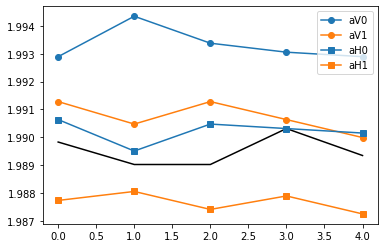

In [81]:
localdf = ames

for col in localdf.columns:
    if col=='analogZero':
        plt.plot(localdf[col], color='k')
    if 'V' in col:
        idx = col[-1]
        plt.plot(localdf[col], label=col, marker='o', color='C{}'.format(idx))
    elif 'H' in col:
        idx = col[-1]
        plt.plot(localdf[col], label=col, marker='s', color='C{}'.format(idx))
plt.legend()

In [74]:
ser.close()